In [ ]:
import pandas as pd
df = pd.read_csv('df_final.csv')
df.head()

# 최종

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. 파생 변수 생성
# ---------------------------------------------------------
state_to_region = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast', 'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South', 'SC': 'South', 'VA': 'South', 'DC': 'South', 'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West', 'WA': 'West'
}

df['REGION'] = df['CARD_HOLDER_STATE'].map(state_to_region).fillna('Unknown')
df['DAYOFWEEK_NUM'] = pd.to_datetime(df['LOCAL_TIME']).dt.dayofweek
df['WEEKEND_SPEND'] = np.where(df['DAYOFWEEK_NUM'] >= 5, df['GROSS_TRANSACTION_AMOUNT'], 0)
df['LUNCH_SPEND'] = np.where(df['Hour'].between(11, 14), df['GROSS_TRANSACTION_AMOUNT'], 0)
df['DINNER_SPEND'] = np.where(df['Hour'].between(17, 20), df['GROSS_TRANSACTION_AMOUNT'], 0)
df['OFFLINE_SPEND'] = np.where(df['CARD_PRESENT_INDICATOR'] == 'Card Present', df['GROSS_TRANSACTION_AMOUNT'], 0)

# 🎯수정: 결제 건별 '신용카드' 지출액 파생변수 생성
# 카드 타입이 결측치인 경우를 방어하기 위해 str() 처리 후 확인
df['CREDIT_SPEND'] = np.where(df['CARD_TYPE'].astype(str).str.contains('Credit', case=False, na=False), df['GROSS_TRANSACTION_AMOUNT'], 0)


# ---------------------------------------------------------
# 2. ACCOUNT_ID 기준 집계 
# ---------------------------------------------------------
account_agg = df.groupby('ACCOUNT_ID').agg(
    LTM_SPEND=('CARD_HOLDER_AVERAGE_LTM_SPEND', 'max'),
    VINTAGE=('CARD_HOLDER_VINTAGE', 'max'),
    TOTAL_LIFETIME_SPEND=('CARD_HOLDER_TOTAL_SPEND', 'max'),
    
    GENERATION=('CARD_HOLDER_GENERATION', 'first'),
    SHOPPER_CLASSIFICATION=('SHOPPER_CLASSIFICATION', 'first'),
    REGION=('REGION', 'first'),
    # ❌ CARD_TYPE ('first' 집계) 삭제!
    
    TOTAL_6M_SPEND=('GROSS_TRANSACTION_AMOUNT', 'sum'),
    TOTAL_WEEKEND_SPEND=('WEEKEND_SPEND', 'sum'),
    TOTAL_LUNCH_SPEND=('LUNCH_SPEND', 'sum'),
    TOTAL_DINNER_SPEND=('DINNER_SPEND', 'sum'),
    TOTAL_OFFLINE_SPEND=('OFFLINE_SPEND', 'sum'),
    TOTAL_CREDIT_SPEND=('CREDIT_SPEND', 'sum') # 🎯 추가: 고객별 신용카드 총 결제액
).reset_index()

# ---------------------------------------------------------
# 3. 결측치 처리 및 비율 변수(Ratio) 생성
# ---------------------------------------------------------
cond_under_12 = account_agg['VINTAGE'] < 12
account_agg.loc[cond_under_12, 'LTM_SPEND'] = account_agg.loc[cond_under_12, 'LTM_SPEND'].fillna(
    account_agg.loc[cond_under_12, 'TOTAL_LIFETIME_SPEND'] / (account_agg.loc[cond_under_12, 'VINTAGE'] + 1)
)
cond_over_12 = account_agg['VINTAGE'] >= 12
account_agg.loc[cond_over_12, 'LTM_SPEND'] = account_agg.loc[cond_over_12, 'LTM_SPEND'].fillna(
    account_agg.loc[cond_over_12, 'TOTAL_6M_SPEND'] / 6
)

total_6m = account_agg['TOTAL_6M_SPEND']
account_agg['WEEKEND_RATIO'] = np.where(total_6m > 0, account_agg['TOTAL_WEEKEND_SPEND'] / total_6m, 0)
account_agg['LUNCH_RATIO'] = np.where(total_6m > 0, account_agg['TOTAL_LUNCH_SPEND'] / total_6m, 0)
account_agg['DINNER_RATIO'] = np.where(total_6m > 0, account_agg['TOTAL_DINNER_SPEND'] / total_6m, 0)
account_agg['OFFLINE_RATIO'] = np.where(total_6m > 0, account_agg['TOTAL_OFFLINE_SPEND'] / total_6m, 0)

# 🎯 수정: 신용카드 사용 비율(Ratio) 변수 생성
# (1에 가까울수록 신용카드 메인, 0에 가까울수록 체크카드(Debit 등) 메인)
account_agg['CREDIT_RATIO'] = np.where(total_6m > 0, account_agg['TOTAL_CREDIT_SPEND'] / total_6m, 0)


# ---------------------------------------------------------
# 4. LTV (Target) 수식 적용
# ---------------------------------------------------------
FEE_RATE = 0.02
account_agg['BASE_LTV'] = account_agg['LTM_SPEND'] * account_agg['VINTAGE'] * FEE_RATE
safe_vintage = account_agg['VINTAGE'].replace(0, 1)
account_agg['HISTORIC_MONTHLY_SPEND'] = account_agg['TOTAL_LIFETIME_SPEND'] / safe_vintage
account_agg['RECENCY_MULTIPLIER'] = np.where(
    account_agg['HISTORIC_MONTHLY_SPEND'] > 0,
    account_agg['LTM_SPEND'] / account_agg['HISTORIC_MONTHLY_SPEND'],
    1.0 
)
account_agg['TARGET_LTV_ADJ'] = account_agg['BASE_LTV'] * account_agg['RECENCY_MULTIPLIER']
account_agg['TARGET_LTV_LOG'] = np.log1p(account_agg['TARGET_LTV_ADJ'])


# ---------------------------------------------------------
# 5. 분석용 데이터셋 구성 및 원-핫 인코딩
# ---------------------------------------------------------
# 연속형 CREDIT_RATIO를 투입
pure_features = [
    'ACCOUNT_ID', 'TARGET_LTV_LOG', 
    'GENERATION', 'SHOPPER_CLASSIFICATION', 'REGION', # 범주형
    'WEEKEND_RATIO', 'LUNCH_RATIO', 'DINNER_RATIO', 'OFFLINE_RATIO', 'CREDIT_RATIO' # 연속형
]

df_pure = account_agg[pure_features].copy()
df_pure[['GENERATION', 'REGION']] = df_pure[['GENERATION', 'REGION']].fillna('Unknown')
df_pure.fillna(0, inplace=True)

df_encoded = pd.get_dummies(df_pure, columns=['GENERATION', 'SHOPPER_CLASSIFICATION', 'REGION'], drop_first=True)

# ---------------------------------------------------------
# 6. 다항식 변환 (연속형 변수 5개로 증가) 및 스케일링
# ---------------------------------------------------------
y = df_encoded['TARGET_LTV_LOG']
X_all = df_encoded.drop(columns=['ACCOUNT_ID', 'TARGET_LTV_LOG'])

# CREDIT_RATIO도 연속형이므로 다항식(제곱/교차항) 변환 대상에 포함
continuous_cols = ['WEEKEND_RATIO', 'LUNCH_RATIO', 'DINNER_RATIO', 'OFFLINE_RATIO', 'CREDIT_RATIO']
categorical_cols = [col for col in X_all.columns if col not in continuous_cols]

X_cont = X_all[continuous_cols]
X_cat = X_all[categorical_cols]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_cont_poly = poly.fit_transform(X_cont)
X_cont_poly_df = pd.DataFrame(X_cont_poly, columns=poly.get_feature_names_out(continuous_cols), index=X_all.index)

X_final = pd.concat([X_cont_poly_df, X_cat], axis=1)

# ---------------------------------------------------------
# 7. 모델 학습 및 결과 출력
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_scaled, y_train)

y_pred = poly_model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)

print(f"✅ 카드 비중(Ratio) 보정 완료! 최종 LTV 다항식 회귀 결과")
print(f"R^2 (설명력): {r2:.4f}")

coefficients = pd.DataFrame({
    'Feature': X_final.columns,
    'Coefficient': poly_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n🔍 다항 회귀 계수 Top 10 (신규 LTV 상승 견인)")
display(coefficients.head(10))
print("\n🔍 다항 회귀 계수 Bottom 10 (신규 LTV 하락 요인)")
display(coefficients.tail(10))

✅ 카드 비중(Ratio) 보정 완료! 최종 LTV 다항식 회귀 결과
R^2 (설명력): 0.0421

🔍 다항 회귀 계수 Top 10 (신규 LTV 상승 견인)


,Feature,Coefficient
2,DINNER_RATIO,0.497424
17,OFFLINE_RATIO^2,0.383498
0,WEEKEND_RATIO,0.355744
25,SHOPPER_CLASSIFICATION_1,0.063076
13,LUNCH_RATIO CREDIT_RATIO,0.059871
22,GENERATION_Millennial,0.057813
23,GENERATION_Silent,0.038039
24,GENERATION_Unknown,0.009502
9,WEEKEND_RATIO CREDIT_RATIO,0.007803
30,REGION_West,0.004043



🔍 다항 회귀 계수 Bottom 10 (신규 LTV 하락 요인)


,Feature,Coefficient
10,LUNCH_RATIO^2,-0.038631
1,LUNCH_RATIO,-0.060387
27,REGION_Northeast,-0.066070
26,SHOPPER_CLASSIFICATION_2,-0.073193
15,DINNER_RATIO OFFLINE_RATIO,-0.218764
19,CREDIT_RATIO^2,-0.222219
4,CREDIT_RATIO,-0.222219
14,DINNER_RATIO^2,-0.262771
3,OFFLINE_RATIO,-0.297246
5,WEEKEND_RATIO^2,-0.351174


In [ ]:
coefficients

,Feature,Coefficient
2,DINNER_RATIO,0.497424
17,OFFLINE_RATIO^2,0.383498
0,WEEKEND_RATIO,0.355744
25,SHOPPER_CLASSIFICATION_1,0.063076
13,LUNCH_RATIO CREDIT_RATIO,0.059871
22,GENERATION_Millennial,0.057813
23,GENERATION_Silent,0.038039
24,GENERATION_Unknown,0.009502
9,WEEKEND_RATIO CREDIT_RATIO,0.007803
30,REGION_West,0.004043


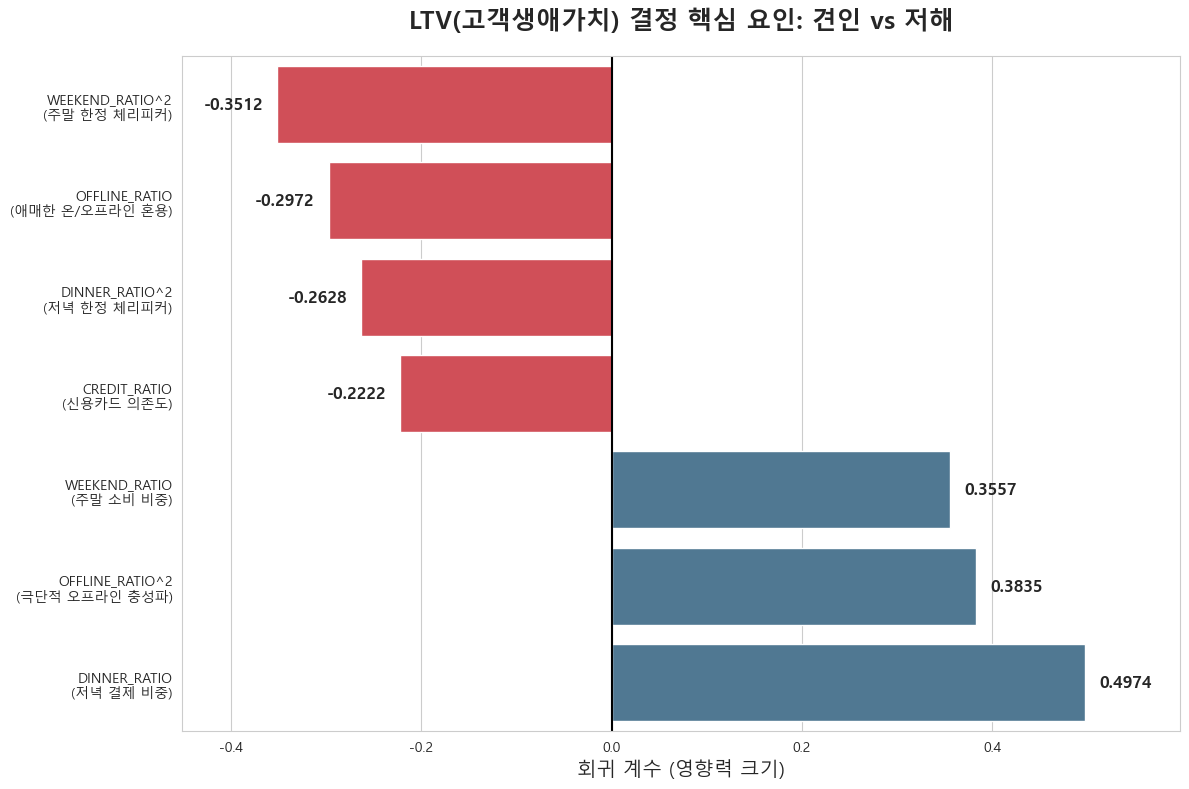

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 데이터 준비
data = {
    'Feature': [
        'DINNER_RATIO\n(저녁 결제 비중)', 
        'OFFLINE_RATIO^2\n(극단적 오프라인 충성파)', 
        'WEEKEND_RATIO\n(주말 소비 비중)',
        'CREDIT_RATIO\n(신용카드 의존도)',
        'DINNER_RATIO^2\n(저녁 한정 체리피커)',
        'OFFLINE_RATIO\n(애매한 온/오프라인 혼용)',
        'WEEKEND_RATIO^2\n(주말 한정 체리피커)'
    ],
    'Coefficient': [0.4974, 0.3835, 0.3557, -0.2222, -0.2628, -0.2972, -0.3512]
}
df_plot = pd.DataFrame(data)

# 계수(Coefficient) 기준으로 정렬
df_plot = df_plot.sort_values(by='Coefficient')

# 색상 설정 (양수는 파란 계열, 음수는 빨간 계열)
colors = ['#E63946' if x < 0 else '#457B9D' for x in df_plot['Coefficient']]

# 2. 차트 그리기
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 폰트 설정 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

ax = sns.barplot(x='Coefficient', y='Feature', data=df_plot, palette=colors)

# 🎯 [수정 부분] x축의 여백을 양옆으로 넉넉하게 확보하여 글자 겹침 방지
min_val = df_plot['Coefficient'].min()
max_val = df_plot['Coefficient'].max()
plt.xlim(min_val - 0.1, max_val + 0.1) # 좌우로 0.1만큼 여백을 강제로 추가합니다.

# 3. 디자인 다듬기
plt.axvline(0, color='black', linewidth=1.5) # 중앙선 강조
plt.title('LTV(고객생애가치) 결정 핵심 요인: 견인 vs 저해', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('회귀 계수 (영향력 크기)', fontsize=14)
plt.ylabel('', fontsize=14)

# 막대 끝에 수치 표시
for p in ax.patches:
    width = p.get_width()
    # 수치 위치 조정 (양수는 막대 오른쪽 끝, 음수는 왼쪽 끝)
    x_offset = 0.015 if width > 0 else -0.015
    ha = 'left' if width > 0 else 'right'
    ax.text(width + x_offset,
            p.get_y() + p.get_height() / 2,
            f'{width:.4f}',
            ha=ha, va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

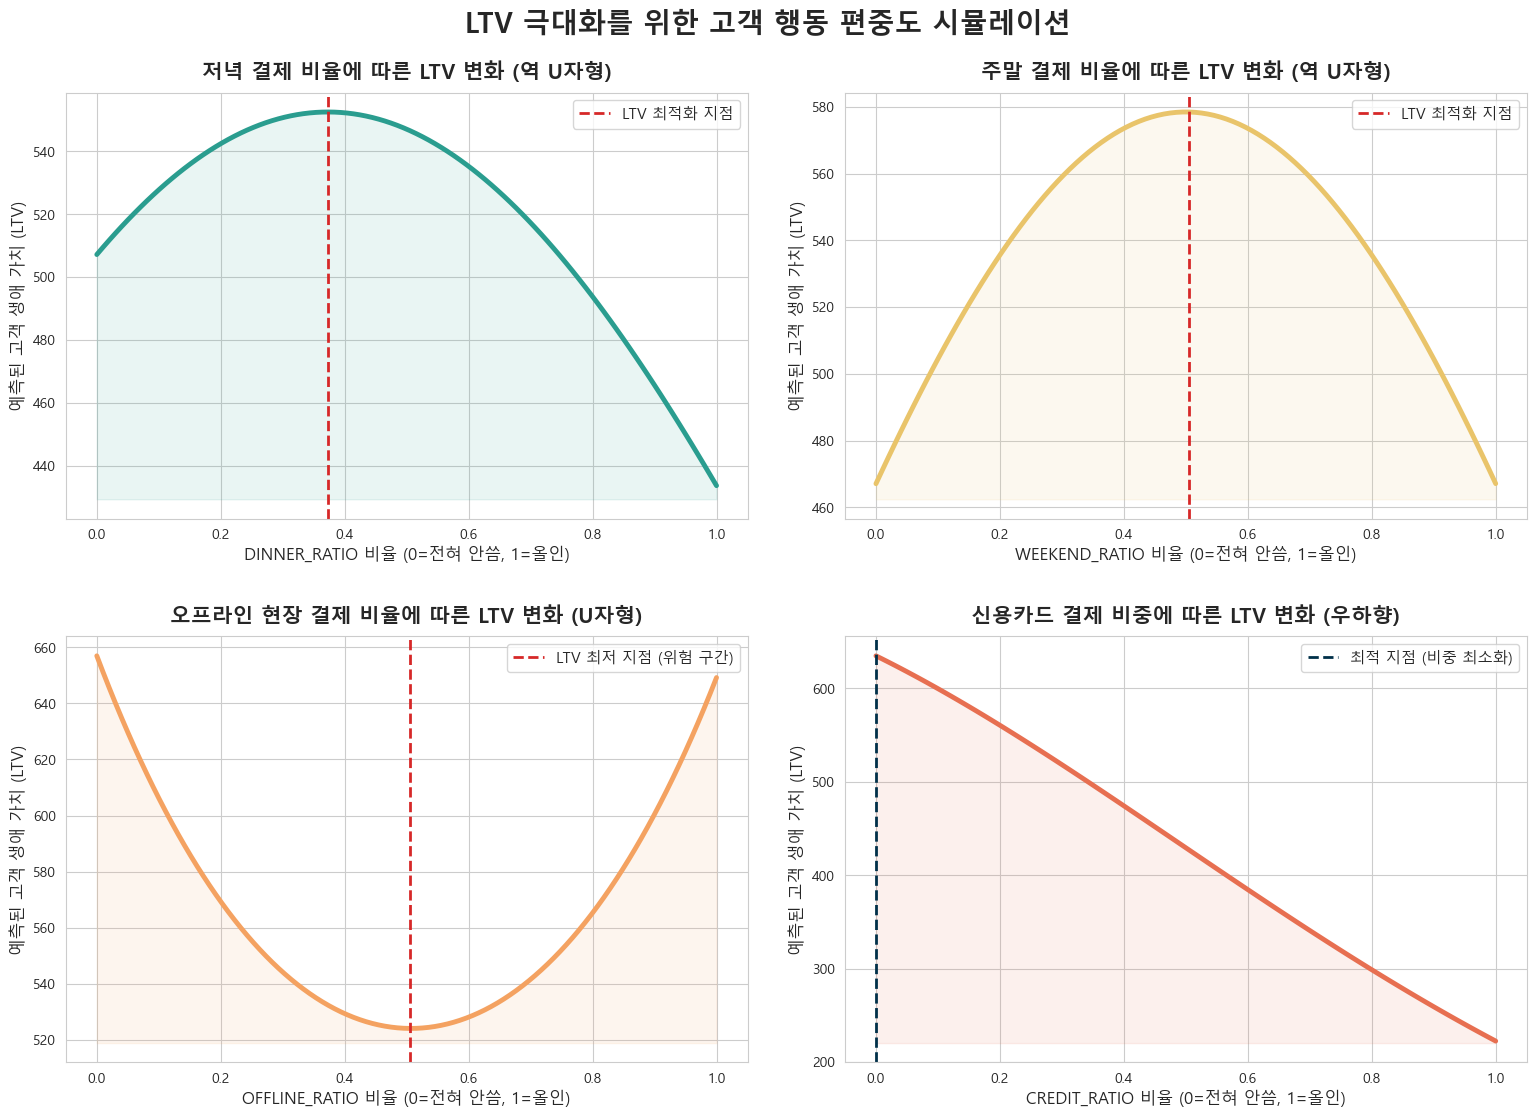

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 🎯 [핵심 해결] Seaborn 테마를 먼저 부르고 -> 폰트를 덮어씌움
sns.set_style("whitegrid") 
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False 

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LTV 극대화를 위한 고객 행동 편중도 시뮬레이션', fontsize=20, fontweight='bold', y=0.95)

# 3. 시뮬레이션 및 시각화 함수
def plot_poly_curve(target_feat, title, ax, color, curve_type):
    # 모든 변수를 전체 고객의 평균값으로 고정
    base_data = pd.DataFrame(X_all.mean()).T
    base_data = pd.concat([base_data]*100, ignore_index=True)
    
    # 타겟 변수만 0에서 1까지 100단계로 변화시킴
    sweep_vals = np.linspace(0, 1, 100)
    base_data[target_feat] = sweep_vals
    
    # 다항식 변환
    X_cont_sim = base_data[continuous_cols]
    X_cat_sim = base_data.drop(columns=continuous_cols)
    
    X_cont_poly_sim = poly.transform(X_cont_sim)
    X_cont_poly_sim_df = pd.DataFrame(X_cont_poly_sim, columns=poly.get_feature_names_out(continuous_cols))
    
    X_final_sim = pd.concat([X_cont_poly_sim_df, X_cat_sim], axis=1)
    
    # 스케일링 및 예측 (로그 변환된 LTV를 원래 금액으로 복원: expm1)
    X_scaled_sim = scaler.transform(X_final_sim)
    pred_log = poly_model.predict(X_scaled_sim)
    pred_ltv = np.expm1(pred_log) 
    
    # 그래프 그리기 (선 및 하단 영역 칠하기)
    ax.plot(sweep_vals, pred_ltv, color=color, linewidth=3.5)
    ax.fill_between(sweep_vals, pred_ltv, pred_ltv.min() * 0.99, color=color, alpha=0.1)
    
    # 최적/최악 지점 찾기 및 수직선 표시
    if curve_type == 'inverted_U': 
        opt_idx = np.argmax(pred_ltv)
        label_text = 'LTV 최적화 지점'
        line_color = '#D62828' # 진한 빨간색
    elif curve_type == 'U_shape':  
        opt_idx = np.argmin(pred_ltv)
        label_text = 'LTV 최저 지점 (위험 구간)'
        line_color = '#D62828'
    else: 
        opt_idx = np.argmax(pred_ltv)
        label_text = '최적 지점 (비중 최소화)'
        line_color = '#003049' # 진한 남색

    opt_x = sweep_vals[opt_idx]
    ax.axvline(opt_x, color=line_color, linestyle='--', linewidth=2, label=label_text)
    
    # 디자인 다듬기
    ax.set_title(title, fontsize=15, pad=10, fontweight='bold')
    ax.set_xlabel(f'{target_feat} 비율 (0=전혀 안씀, 1=올인)', fontsize=12)
    ax.set_ylabel('예측된 고객 생애 가치 (LTV)', fontsize=12)
    ax.legend(fontsize=11)

# 4. 4가지 핵심 변수 시각화 실행
plot_poly_curve('DINNER_RATIO', '저녁 결제 비율에 따른 LTV 변화 (역 U자형)', axes[0, 0], '#2A9D8F', 'inverted_U')
plot_poly_curve('WEEKEND_RATIO', '주말 결제 비율에 따른 LTV 변화 (역 U자형)', axes[0, 1], '#E9C46A', 'inverted_U')
plot_poly_curve('OFFLINE_RATIO', '오프라인 현장 결제 비율에 따른 LTV 변화 (U자형)', axes[1, 0], '#F4A261', 'U_shape')
plot_poly_curve('CREDIT_RATIO', '신용카드 결제 비중에 따른 LTV 변화 (우하향)', axes[1, 1], '#E76F51', 'downward')

plt.tight_layout(pad=3.0)
plt.show()